# Calcium–IP3 Oscillations


This notebook closes module C. It uses a two-variable calcium–IP3 model to show how a biologically realistic oscillator behaves in state space — building the bridge to module D, where the same oscillator is embedded in a spatial grid to produce travelling waves.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## Model

$$\dot{X} = a - \frac{m_2 X}{1+X} + \frac{m_3 Y}{k_1+Y}\cdot\frac{X^2}{k_a+X^2} + Y - k X$$

$$\dot{Y} = \frac{m_2 X}{1+X} - \frac{m_3 Y}{k_1+Y}\cdot\frac{X^2}{k_a+X^2} - Y$$

X = cytosolic Ca²⁺, Y = IP3; **a** is the bifurcation parameter (calcium input rate).

In [2]:
def model(t, state, a, m2, m3, ka, k, k1):
    """Calcium-IP3 ODE system."""
    X, Y = state
    
    ip3_term = (m3 * Y / (k1 + Y)) * X**2 / (ka + X**2)
    
    dXdt = a - m2*X/(1+X) + ip3_term + Y - k*X
    dYdt =     m2*X/(1+X) - ip3_term       - Y
    
    return [dXdt, dYdt]


# Fixed model parameters
PARAMS = dict(m2=20, m3=23, ka=0.8, k=0.8, k1=0.8)

# Default initial conditions
IC_DEFAULT = [0.48, 2.54]

## 1. Bifurcation Diagram

In [3]:
def asymptotic_extrema(a_val, ic, params, t_trans=500, t_anal=200):
    """
    Simulate to t_trans + t_anal, then return min/max of X and Y
    over the analysis window [t_trans, t_trans+t_anal].
    Raises RuntimeError if integration fails.
    """
    args = (a_val, params['m2'], params['m3'],
            params['ka'], params['k'], params['k1'])
    sol = solve_ivp(
        model, [0, t_trans + t_anal], ic,
        args=args, method='LSODA', dense_output=True,
        rtol=1e-8, atol=1e-10
    )
    if not sol.success:
        raise RuntimeError(sol.message)
    t_eval = np.linspace(t_trans, t_trans + t_anal, 2000)
    s = sol.sol(t_eval)
    return s[0].min(), s[0].max(), s[1].min(), s[1].max()


def run_bifurcation_scan(a_min, a_max, n_points=100, ic=None,
                         params=None, t_trans=500, t_anal=200, verbose=True):
    """
    Scan bifurcation parameter 'a' using numerical continuation:
    each step starts from the endpoint of the previous run.
    Returns arrays: a_vals, X_mins, X_maxs, Y_mins, Y_maxs.
    """
    if params is None:
        params = PARAMS
    if ic is None:
        ic = IC_DEFAULT.copy()

    a_vals = np.linspace(a_min, a_max, n_points)
    X_mins, X_maxs, Y_mins, Y_maxs = [], [], [], []
    current_ic = list(ic)

    if verbose:
        print(f'Scanning a ∈ [{a_min:.3f}, {a_max:.3f}]  ({n_points} points) ...')

    for i, a in enumerate(a_vals):
        try:
            xn, xx, yn, yx = asymptotic_extrema(
                a, current_ic, params, t_trans, t_anal)
            X_mins.append(xn); X_maxs.append(xx)
            Y_mins.append(yn); Y_maxs.append(yx)
            # Continuation: seed next step from midpoint of current limit cycle
            current_ic = [(xn+xx)/2, (yn+yx)/2]
        except Exception as e:
            if verbose:
                print(f'  Warning at a={a:.4f}: {e}')
            prev = [X_mins[-1], X_maxs[-1], Y_mins[-1], Y_maxs[-1]] \
                   if X_mins else [np.nan]*4
            X_mins.append(prev[0]); X_maxs.append(prev[1])
            Y_mins.append(prev[2]); Y_maxs.append(prev[3])

    if verbose:
        print('Done.')
    return (np.array(a_vals),
            np.array(X_mins), np.array(X_maxs),
            np.array(Y_mins), np.array(Y_maxs))

In [4]:
# ── Scan settings (edit these) ───────────────────────────────────────────
A_MIN    = 0.30   # lower bound for bifurcation parameter
A_MAX    = 0.35   # upper bound
N_POINTS = 50    # number of scan points
T_TRANS  = 500    # transient length (time units)
T_ANAL   = 200    # analysis window length
# ─────────────────────────────────────────────────────────────────────────

a_vals, X_mins, X_maxs, Y_mins, Y_maxs = run_bifurcation_scan(
    A_MIN, A_MAX, n_points=N_POINTS,
    t_trans=T_TRANS, t_anal=T_ANAL
)

Scanning a ∈ [0.300, 0.350]  (50 points) ...
Done.


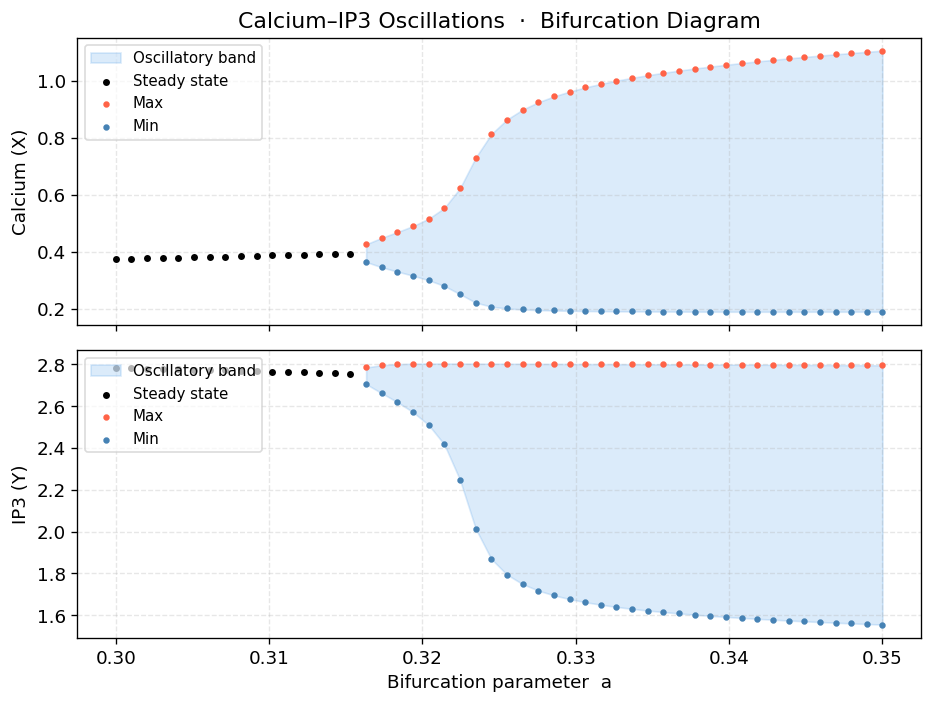

In [5]:
def plot_bifurcation(a_vals, X_mins, X_maxs, Y_mins, Y_maxs, a_pick=None):
    """Two-panel bifurcation diagram for Calcium (X) and IP3 (Y)."""
    osc_color = '#4C9BE8'
    ss_color  = 'k'

    # Identify oscillatory vs steady-state points
    X_amp = X_maxs - X_mins
    osc   = X_amp > 0.01

    fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

    for ax, mins, maxs, label in zip(
            axes,
            [X_mins, Y_mins],
            [X_maxs, Y_maxs],
            ['Calcium (X)', 'IP3 (Y)']):

        # Shaded band in oscillatory region
        ax.fill_between(a_vals, mins, maxs,
                        where=osc, alpha=0.2, color=osc_color,
                        label='Oscillatory band')

        # Steady-state points (min == max collapsed to a dot)
        ax.scatter(a_vals[~osc], maxs[~osc],
                   s=10, color=ss_color, zorder=3, label='Steady state')

        # Limit cycle extrema
        ax.scatter(a_vals[osc], maxs[osc],
                   s=8, color='tomato', zorder=3, label='Max')
        ax.scatter(a_vals[osc], mins[osc],
                   s=8, color='steelblue', zorder=3, label='Min')

        if a_pick is not None:
            ax.axvline(a_pick, color='green', lw=1.5,
                       ls='--', label=f'a = {a_pick}')

        ax.set_ylabel(label)
        ax.grid(True, alpha=0.3, ls='--')
        ax.legend(loc='upper left', fontsize=9, framealpha=0.7)

    axes[-1].set_xlabel('Bifurcation parameter  a')
    axes[0].set_title('Calcium–IP3 Oscillations  ·  Bifurcation Diagram')
    fig.tight_layout()
    return fig


fig_bif = plot_bifurcation(a_vals, X_mins, X_maxs, Y_mins, Y_maxs)
plt.show()

## 2. Pick Parameter

Choose a value of **a** from the bifurcation diagram above and set it here. The green dashed line will mark your choice when you re-run the plot cell.

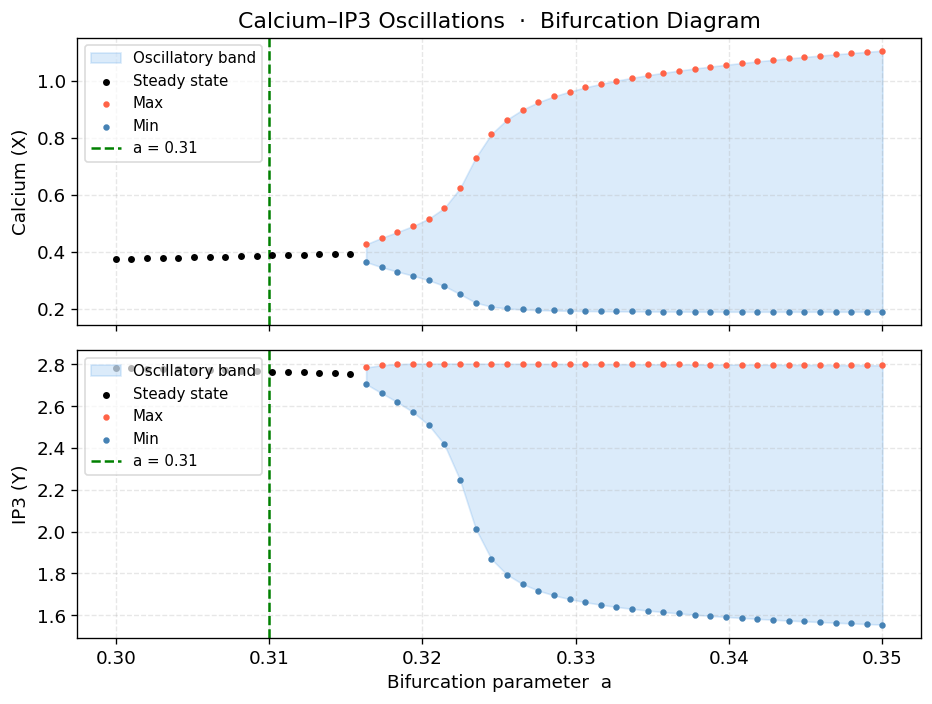

In [13]:
# ── Set your chosen parameter value ──────────────────────────────────────
a_pick = 0.31 # <-- edit this
# ─────────────────────────────────────────────────────────────────────────

# Re-draw bifurcation diagram with marker
fig_bif = plot_bifurcation(a_vals, X_mins, X_maxs, Y_mins, Y_maxs,
                           a_pick=a_pick)
plt.show()

## 3. Time Series

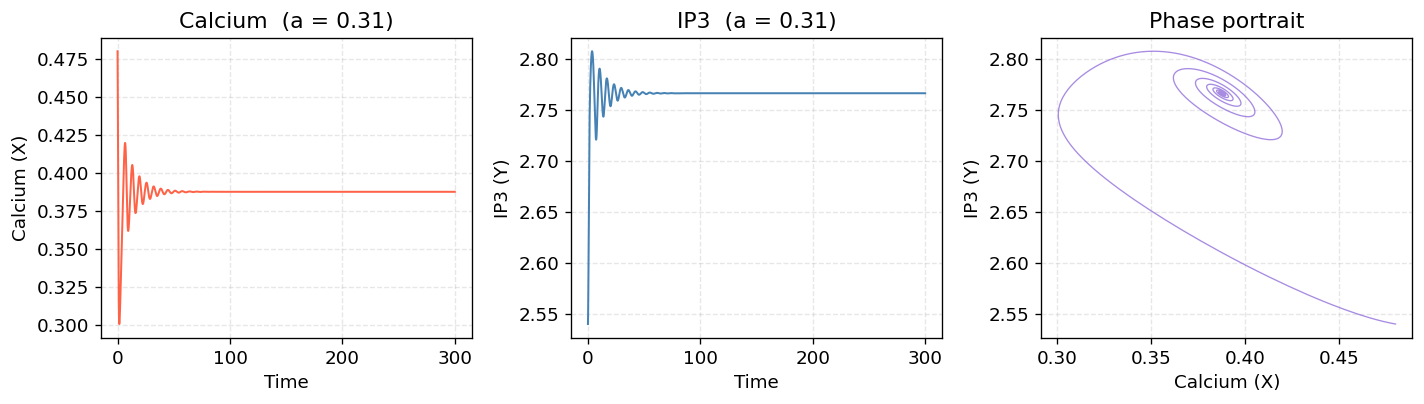

Final state: X = 0.3875,  Y = 2.7662


In [14]:
def run_time_series(a_val, ic=None, params=None, t_end=200, max_step=0.05):
    """Simulate from ic for t_end time units; return (t, X, Y)."""
    if params is None:
        params = PARAMS
    if ic is None:
        ic = IC_DEFAULT
    args = (a_val, params['m2'], params['m3'],
            params['ka'], params['k'], params['k1'])
    sol = solve_ivp(
        model, [0, t_end], ic, args=args,
        method='LSODA', max_step=max_step,
        rtol=1e-9, atol=1e-11
    )
    return sol.t, sol.y[0], sol.y[1]


def plot_time_series(t, X, Y, a_val):
    """Three-panel plot: X(t), Y(t), and X-Y phase portrait."""
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

    axes[0].plot(t, X, color='tomato', lw=1.2)
    axes[0].set_xlabel('Time')
    axes[0].set_ylabel('Calcium (X)')
    axes[0].set_title(f'Calcium  (a = {a_val})')

    axes[1].plot(t, Y, color='steelblue', lw=1.2)
    axes[1].set_xlabel('Time')
    axes[1].set_ylabel('IP3 (Y)')
    axes[1].set_title(f'IP3  (a = {a_val})')

    axes[2].plot(X, Y, color='mediumpurple', lw=0.8, alpha=0.8)
    axes[2].set_xlabel('Calcium (X)')
    axes[2].set_ylabel('IP3 (Y)')
    axes[2].set_title('Phase portrait')

    for ax in axes:
        ax.grid(True, alpha=0.3, ls='--')
    fig.tight_layout()
    return fig


# ── Simulation settings ───────────────────────────────────────────────────
T_END = 300   # total simulation time
# ─────────────────────────────────────────────────────────────────────────

t, X, Y = run_time_series(a_pick, t_end=T_END)
fig_ts  = plot_time_series(t, X, Y, a_pick)
plt.show()

print(f'Final state: X = {X[-1]:.4f},  Y = {Y[-1]:.4f}')

## 4. Excitability — Pulse Perturbations

Near the Hopf bifurcation the system is **excitable**: small perturbations return smoothly to the steady state, while perturbations above a threshold trigger a full calcium spike (analogous to a neuronal action potential). The cell below applies a series of pulses of increasing amplitude to X (cytosolic Ca²⁺) and plots the responses side-by-side.

> **Tip:** set `a_pick` (Section 2) to a value *just below* the Hopf point (e.g. `a ≈ 0.31`) to see the sub-/supra-threshold contrast most clearly.

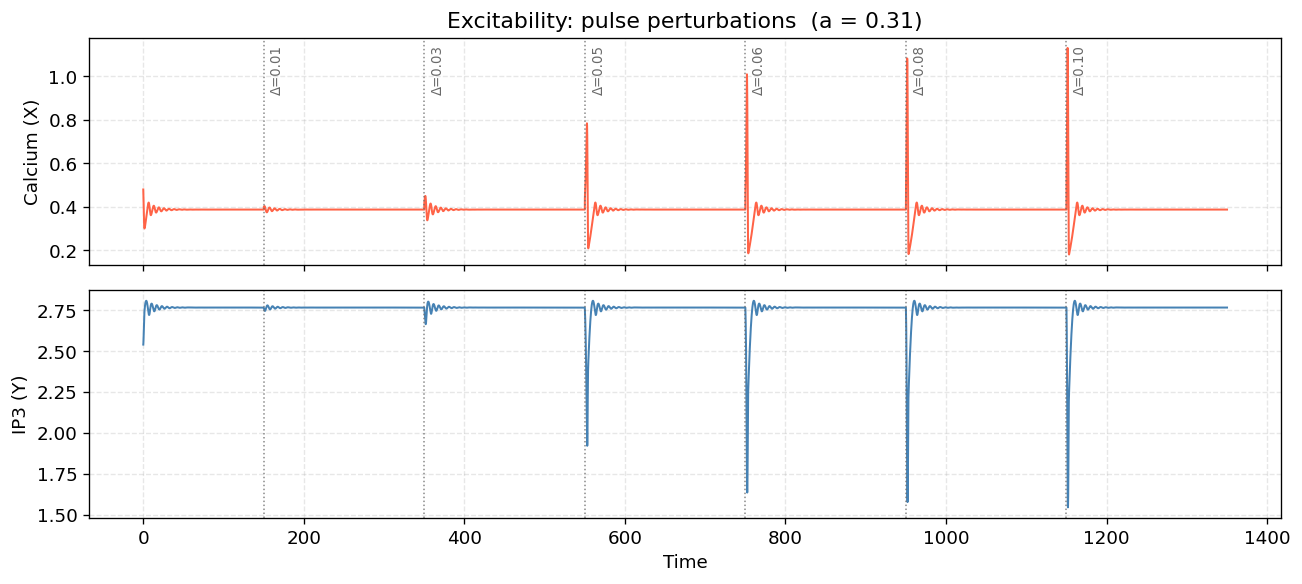

Pulse amplitudes: [0.01  0.028 0.046 0.064 0.082 0.1  ]


In [15]:
def simulate_with_pulses(a_val, pulse_amplitudes, t_settle=100,
                          t_between=150, ic=None, params=None,
                          max_step=0.05):
    """
    Simulate with a sequence of instantaneous positive pulses applied to X.

    Parameters
    ----------
    a_val            : bifurcation parameter value
    pulse_amplitudes : list of ΔX values (one per pulse, increasing)
    t_settle         : initial run time to reach steady state before first pulse
    t_between        : time allowed for recovery between consecutive pulses
    """
    if params is None:
        params = PARAMS
    if ic is None:
        ic = IC_DEFAULT
    args = (a_val, params['m2'], params['m3'],
            params['ka'], params['k'], params['k1'])

    t_segs, X_segs, Y_segs = [], [], []
    pulse_events = []          # (t_pulse, amplitude)
    current_ic = list(ic)
    t_offset   = 0.0

    def _run(t0, t1, ic0):
        return solve_ivp(
            model, [t0, t1], ic0, args=args,
            method='LSODA', max_step=max_step,
            rtol=1e-9, atol=1e-11
        )

    # ── Initial settle ────────────────────────────────────────────────────
    sol = _run(0, t_settle, current_ic)
    t_segs.append(sol.t)
    X_segs.append(sol.y[0])
    Y_segs.append(sol.y[1])
    current_ic = [sol.y[0, -1], sol.y[1, -1]]
    t_offset   = float(sol.t[-1])

    # ── Pulses ────────────────────────────────────────────────────────────
    for amp in pulse_amplitudes:
        # Instantaneous kick to X
        current_ic[0] += amp
        pulse_events.append((t_offset, amp))

        # Evolve for t_between
        sol = _run(t_offset, t_offset + t_between, current_ic)
        t_segs.append(sol.t[1:])     # drop first point (duplicate of t_offset)
        X_segs.append(sol.y[0, 1:])
        Y_segs.append(sol.y[1, 1:])
        current_ic = [sol.y[0, -1], sol.y[1, -1]]
        t_offset   = float(sol.t[-1])

    return (np.concatenate(t_segs),
            np.concatenate(X_segs),
            np.concatenate(Y_segs),
            pulse_events)


def plot_pulse_response(t, X, Y, pulse_events, a_val):
    """Two-panel plot of X(t) and Y(t) with annotated pulse markers."""
    fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)

    axes[0].plot(t, X, color='tomato',    lw=1.2)
    axes[1].plot(t, Y, color='steelblue', lw=1.2)

    y0_top = axes[0].get_ylim()[1]   # will be updated after autoscale

    for ax in axes:
        for t_p, _ in pulse_events:
            ax.axvline(t_p, color='dimgray', lw=0.9, ls=':', alpha=0.8)

    # Annotations on X panel: show ΔX above each pulse line
    axes[0].set_ylabel('Calcium (X)')
    axes[0].set_title(f'Excitability: pulse perturbations  (a = {a_val})')

    # Use axes transform so y-position is always at the top
    for t_p, amp in pulse_events:
        axes[0].annotate(
            f'Δ={amp:.2f}',
            xy=(t_p, 1), xycoords=('data', 'axes fraction'),
            xytext=(4, -4), textcoords='offset points',
            fontsize=8, color='dimgray', rotation=90, va='top'
        )

    axes[1].set_ylabel('IP3 (Y)')
    axes[1].set_xlabel('Time')

    for ax in axes:
        ax.grid(True, alpha=0.3, ls='--')

    fig.tight_layout()
    return fig


# ── Pulse settings (edit these) ───────────────────────────────────────────
N_PULSES   = 6      # number of pulses
AMP_MIN    = 0.01   # smallest pulse amplitude (ΔX)
AMP_MAX    = 0.10   # largest  pulse amplitude (ΔX)
T_SETTLE   = 150    # time to reach steady state before first pulse
T_BETWEEN  = 200    # recovery time between pulses
# ─────────────────────────────────────────────────────────────────────────

pulse_amplitudes = np.linspace(AMP_MIN, AMP_MAX, N_PULSES)

t_p, X_p, Y_p, pulse_events = simulate_with_pulses(
    a_pick, pulse_amplitudes,
    t_settle=T_SETTLE, t_between=T_BETWEEN
)

fig_pulse = plot_pulse_response(t_p, X_p, Y_p, pulse_events, a_pick)
plt.show()

print('Pulse amplitudes:', np.round(pulse_amplitudes, 3))